# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/india_startup_master_dataset.csv")

df.head()

,year,state,industry,startup_count,nsva,india_internet_penetration,india_population,state_total_startups,sector_share,sector_share_pct,startup_growth_pct,india_internet_growth_pp,india_total_startups,industry_share_national
0,2017,Andhra Pradesh,AI,2.0,645027.0,18.200001,1.359657e+09,103.0,0.019417,1.941748,2475.0,1.700001,5473.0,0.014069
1,2017,Andhra Pradesh,AR VR (Augmented + Virtual Reality),1.0,645027.0,18.200001,1.359657e+09,103.0,0.009709,0.970874,2475.0,1.700001,5473.0,0.007309
2,2017,Andhra Pradesh,Advertising,3.0,645027.0,18.200001,1.359657e+09,103.0,0.029126,2.912621,2475.0,1.700001,5473.0,0.009867
3,2017,Andhra Pradesh,Agriculture,1.0,645027.0,18.200001,1.359657e+09,103.0,0.009709,0.970874,2475.0,1.700001,5473.0,0.032341
4,2017,Andhra Pradesh,Analytics,1.0,645027.0,18.200001,1.359657e+09,103.0,0.009709,0.970874,2475.0,1.700001,5473.0,0.011511


In [2]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,8756.0,NaN,NaN,NaN,2021.203403,2.393088,2017.0,2019.0,2021.0,2023.0,2025.0
state,8756,32,Maharashtra,472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,8756,56,IT Services,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
startup_count,8756.0,NaN,NaN,NaN,19.817268,41.033612,1.0,2.0,6.0,18.0,575.0
nsva,8756.0,NaN,NaN,NaN,955100.098218,748581.221321,7396.0,410802.0,786562.0,1329455.0,3821420.0
india_internet_penetration,8756.0,NaN,NaN,NaN,47.48647,16.911324,18.200001,29.5235,49.258099,60.2523,70.0
india_population,8756.0,NaN,NaN,NaN,1415817096.605984,30461915.193794,1359657400.0,1389030312.0,1414203896.0,1438069596.0,1463865525.0
state_total_startups,8756.0,NaN,NaN,NaN,1012.509137,1133.539936,1.0,235.0,620.0,1386.0,5816.0
sector_share,8756.0,NaN,NaN,NaN,0.02878,0.046855,0.000174,0.006317,0.013966,0.032366,1.0
sector_share_pct,8756.0,NaN,NaN,NaN,2.878026,4.685515,0.017437,0.63168,1.396648,3.236578,100.0


In [3]:
df.groupby("year")["startup_count"].sum()

year
2017     5394.0
2018     8847.0
2019    11716.0
2020    14690.0
2021    20102.0
2022    26342.0
2023    34462.0
2024    33778.0
2025    18189.0
Name: startup_count, dtype: float64

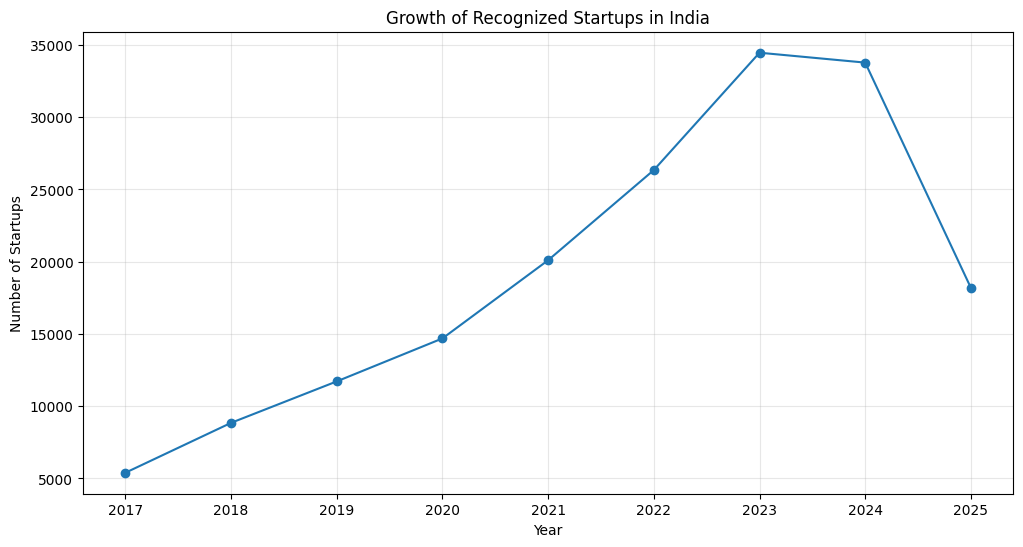

In [4]:
yearly = (
    df.groupby("year", as_index=False)
      .agg(total_startups=("startup_count", "sum"))
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly["year"],
    yearly["total_startups"],
    marker="o"
)

plt.title("Growth of Recognized Startups in India")
plt.xlabel("Year")
plt.ylabel("Number of Startups")
plt.grid(alpha=0.3)

plt.show()

In [5]:
yearly["yoy_growth_pct"] = (
    yearly["total_startups"]
    .pct_change() * 100
)

yearly

,year,total_startups,yoy_growth_pct
0,2017,5394.0,NaN
1,2018,8847.0,64.015573
2,2019,11716.0,32.429072
3,2020,14690.0,25.384090
4,2021,20102.0,36.841389
5,2022,26342.0,31.041687
6,2023,34462.0,30.825298
7,2024,33778.0,-1.984795
8,2025,18189.0,-46.151341


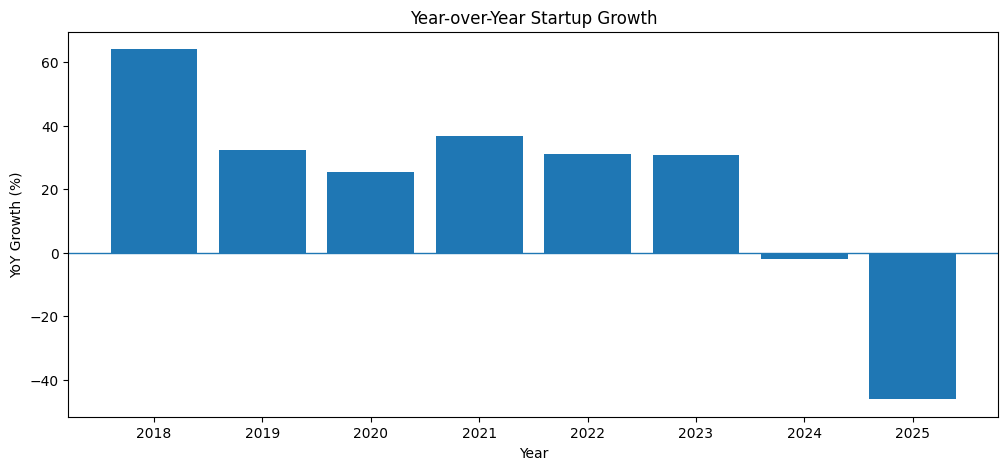

In [6]:
plt.figure(figsize=(12,5))

plt.bar(
    yearly["year"],
    yearly["yoy_growth_pct"]
)

plt.axhline(0, linewidth=1)

plt.title("Year-over-Year Startup Growth")
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")

plt.show()

In [7]:
state_summary = (
    df.groupby("state", as_index=False)
      .agg(
          startups=("startup_count", "sum"),
          nsva=("nsva", "max")
      )
      .sort_values("startups", ascending=False)
)

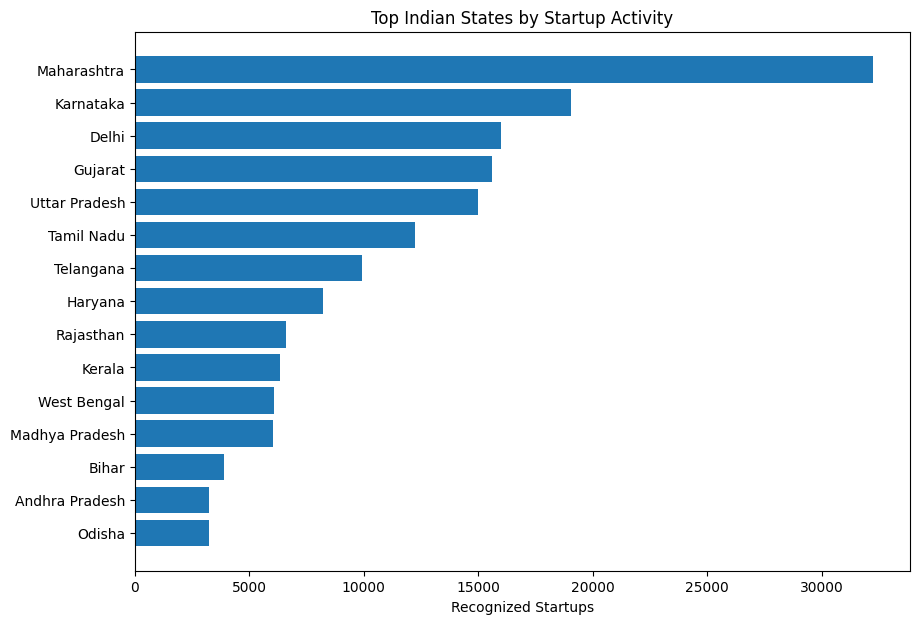

In [8]:
top_states = state_summary.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_states["state"][::-1],
    top_states["startups"][::-1]
)

plt.title("Top Indian States by Startup Activity")
plt.xlabel("Recognized Startups")

plt.show()

In [9]:
latest_year = df["year"].max()

latest_state = (
    df[df["year"] == latest_year]
    .groupby("state", as_index=False)
    .agg(
        startups=("startup_count", "sum"),
        nsva=("nsva", "max")
    )
    .sort_values("startups", ascending=False)
)

latest_state.head(15)

,state,startups,nsva
7,Maharashtra,4422.0,3821420.0
3,Gujarat,2592.0,2295700.0
5,Karnataka,2487.0,2696034.0
10,Tamil Nadu,1724.0,2896553.0
11,Telangana,1679.0,1481185.0
9,Rajasthan,1049.0,1521722.0
6,Madhya Pradesh,943.0,1416661.0
13,West Bengal,905.0,1662856.0
0,Andhra Pradesh,695.0,1441786.0
2,Bihar,686.0,969815.0


In [10]:
industry_summary = (
    df.groupby("industry", as_index=False)
      .agg(
          startups=("startup_count", "sum")
      )
      .sort_values("startups", ascending=False)
)

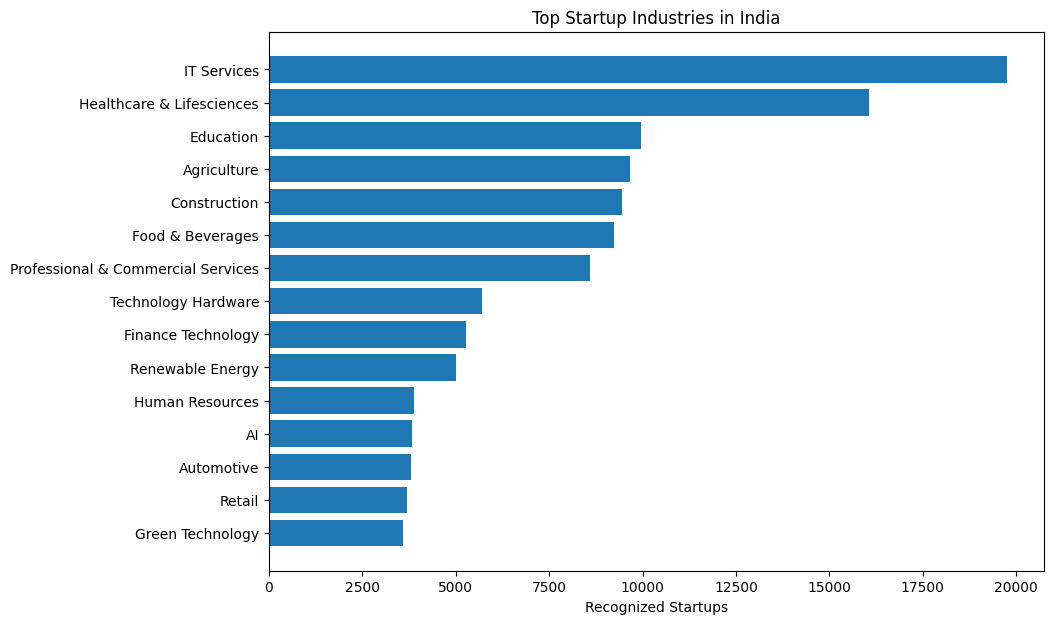

In [11]:
top_industries = industry_summary.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_industries["industry"][::-1],
    top_industries["startups"][::-1]
)

plt.title("Top Startup Industries in India")
plt.xlabel("Recognized Startups")

plt.show()

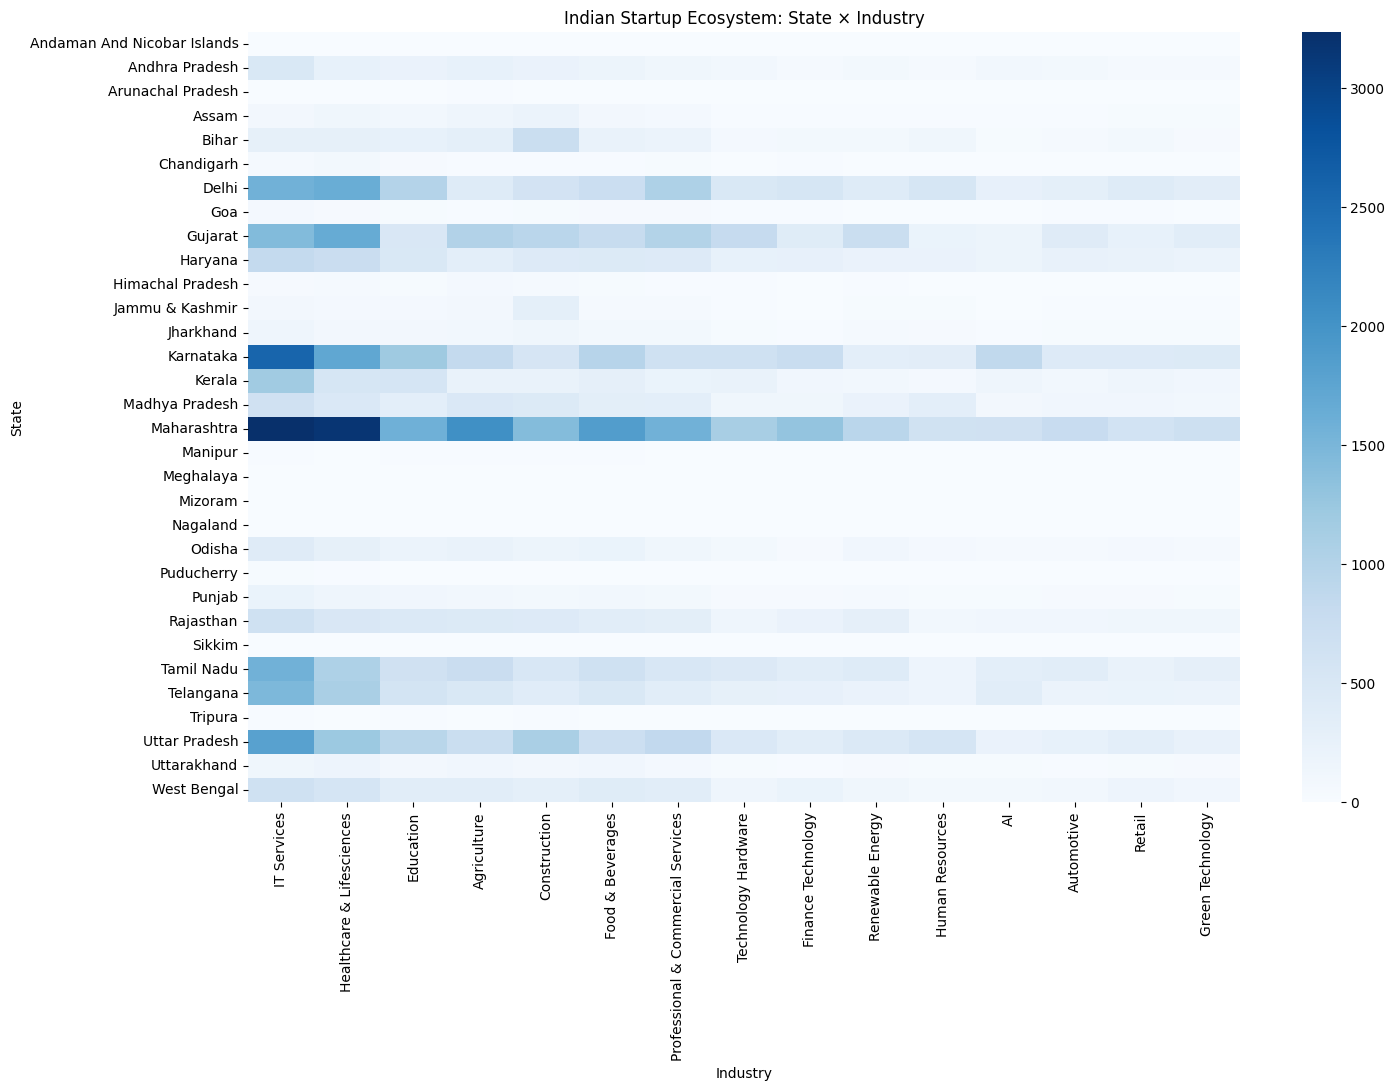

In [12]:
state_industry = pd.pivot_table(
    df,
    values="startup_count",
    index="state",
    columns="industry",
    aggfunc="sum",
    fill_value=0
)

top_15_industries = (
    df.groupby("industry")["startup_count"]
      .sum()
      .nlargest(15)
      .index
)

heatmap_data = state_industry[
    top_15_industries
]



plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_data,
    cmap="Blues"
)

plt.title("Indian Startup Ecosystem: State × Industry")
plt.xlabel("Industry")
plt.ylabel("State")

plt.show()

In [13]:
state_year = (
    df.groupby(
        ["state", "year"],
        as_index=False
    )
    .agg(
        startups=("startup_count", "sum"),
        nsva=("nsva", "max")
    )
)

In [14]:
# GROWTH

state_year["startup_growth_pct"] = (
    state_year
    .groupby("state")["startups"]
    .pct_change() * 100
)

In [15]:
latest_state_growth = (
    state_year[
        state_year["year"] == state_year["year"].max()
    ]
    .sort_values(
        "startup_growth_pct",
        ascending=False
    )
)

latest_state_growth.head(15)

,state,year,startups,nsva,startup_growth_pct
21,Arunachal Pradesh,2025,25.0,40196.0,92.307692
15,Andhra Pradesh,2025,695.0,1441786.0,14.686469
242,Uttarakhand,2025,265.0,293455.0,-1.486989
219,Telangana,2025,1679.0,1481185.0,-7.186291
95,Jammu & Kashmir,2025,252.0,206673.0,-8.363636
172,Odisha,2025,465.0,751750.0,-15.145985
196,Rajasthan,2025,1049.0,1521722.0,-15.810594
251,West Bengal,2025,905.0,1662856.0,-18.247516
38,Bihar,2025,686.0,969815.0,-18.527316
129,Madhya Pradesh,2025,943.0,1416661.0,-21.021776


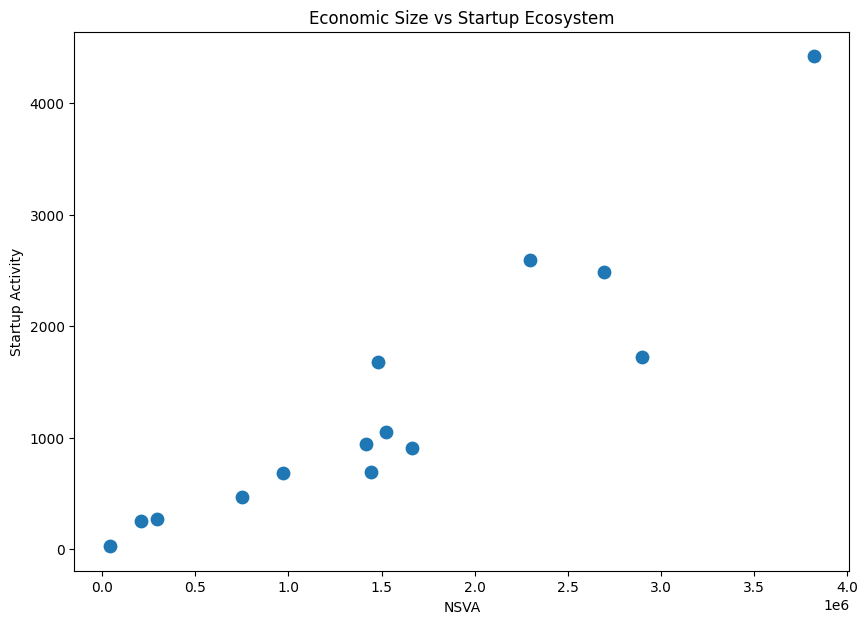

In [16]:
latest = state_year[
    state_year["year"] == state_year["year"].max()
].copy()

plt.figure(figsize=(10,7))

plt.scatter(
    latest["nsva"],
    latest["startups"],
    s=80
)

plt.xlabel("NSVA")
plt.ylabel("Startup Activity")
plt.title(
    "Economic Size vs Startup Ecosystem"
)

plt.show()

In [17]:
df[
    ["state", "industry", "startup_count", "sector_share"]
].sort_values(
    "sector_share",
    ascending=False
).head(20)

hhi = (
    df.groupby(
        ["state", "industry"]
    )["startup_count"]
    .sum()
    .reset_index()
)

state_totals = (
    hhi.groupby("state")["startup_count"]
       .transform("sum")
)

hhi["share"] = (
    hhi["startup_count"] /
    state_totals
)

hhi["share_squared"] = hhi["share"] ** 2

state_hhi = (
    hhi.groupby("state")["share_squared"]
       .sum()
       .reset_index(name="industry_hhi")
)

state_hhi.sort_values(
    "industry_hhi",
    ascending=False
).head(10)

,state,industry_hhi
2,Arunachal Pradesh,0.145448
19,Mizoram,0.119001
25,Sikkim,0.107438
0,Andaman And Nicobar Islands,0.097959
11,Jammu & Kashmir,0.091180
4,Bihar,0.070072
28,Tripura,0.069743
22,Puducherry,0.064974
14,Kerala,0.064404
18,Meghalaya,0.063333
